In [40]:
import pandas as pd
import numpy as np
import csv
import os

In [41]:
folder_name = '../csv_folder/source'

for _, _, files in os.walk(folder_name):
    for file in files:
        if file.endswith('.csv'):
            file_name = os.path.join(folder_name, file)
            print(file_name)

../csv_folder/source\Source1-10sec_eeg_fnirs_power_sliced.csv
../csv_folder/source\Source1-5sec_eeg_fnirs_power_sliced.csv
../csv_folder/source\Source2-full_eeg_fnirs_psd.csv
../csv_folder/source\Source3-fnirs_time_domain_features.csv


In [42]:
filename = 'Source1-10sec_eeg_fnirs_power_sliced.csv'
file = os.path.join(folder_name, filename)
df = pd.read_csv(file)
print(df.columns[2])

eeg_act-0_feat-Px_band-Delta_ch-0


In [43]:
types = set()
acts = set()
feats = set()
bands = set()

for col in df.columns:
    parts = col.split('_')
    types.add(parts[0])
    for part in parts:
        if part.startswith('act'):
            acts.add(part)
        elif part.startswith('feat'):
            feats.add(part)
        elif part.startswith('band'):
            bands.add(part)

print(types)
print(acts)
print(feats)
print(bands)

{'eeg', 'fnirs', 'Unnamed: 0', 'label'}
{'act-5', 'act-2', 'act-1', 'act-0', 'act-3', 'act-4'}
{'feat-Pd', 'feat-Pm', 'feat-Px'}
{'band-Alpha', 'band-Delta', 'band-vlfo', 'band-Gamma1', 'band-Theta', 'band-lfo', 'band-Beta', 'band-Gamma2'}


In [44]:
def get_features(column_name: str):
    parts = column_name.split('_')
    src_type = parts[0]
    act = None
    feat = None
    band = None
    for part in parts:
        if part.startswith('act'):
            act = part
        elif part.startswith('feat'):
            feat = part
        elif part.startswith('band'):
            band = part
    return src_type, act, feat, band

In [47]:
import matplotlib.pyplot as plt


def display_one_row(row):
    signals = {
        src_type: { act: { feat: { band: [] for band in bands } for feat in feats } for act in acts } for src_type in types
    }

    for col in df.columns:
        src_type, act, feat, band = get_features(col)
        if act is not None and feat is not None and band is not None:
            signals[src_type][act][feat][band].append(row[col])

    feat_len = len(feats)
    band_len = len(bands)
    act = 'act-0'
    src_type = 'eeg'
    
    fig, axs = plt.subplots(feat_len, band_len, figsize=(12, 8), dpi=150)  # 调整纵横比和像素密度
    fig.suptitle('eeg act-0', fontsize=16)
    
    for i, feat in enumerate(feats):
        for j, band in enumerate(bands):
            axs[i, j].plot(signals[src_type][act][feat][band])
            axs[i, j].set_title(f"{feat} {band}", fontsize=10)
            axs[i, j].tick_params(axis='both', which='major', labelsize=8)

    plt.tight_layout(rect=[0, 0, 1, 0.96])  # 调整布局避免标题重叠
    plt.show()

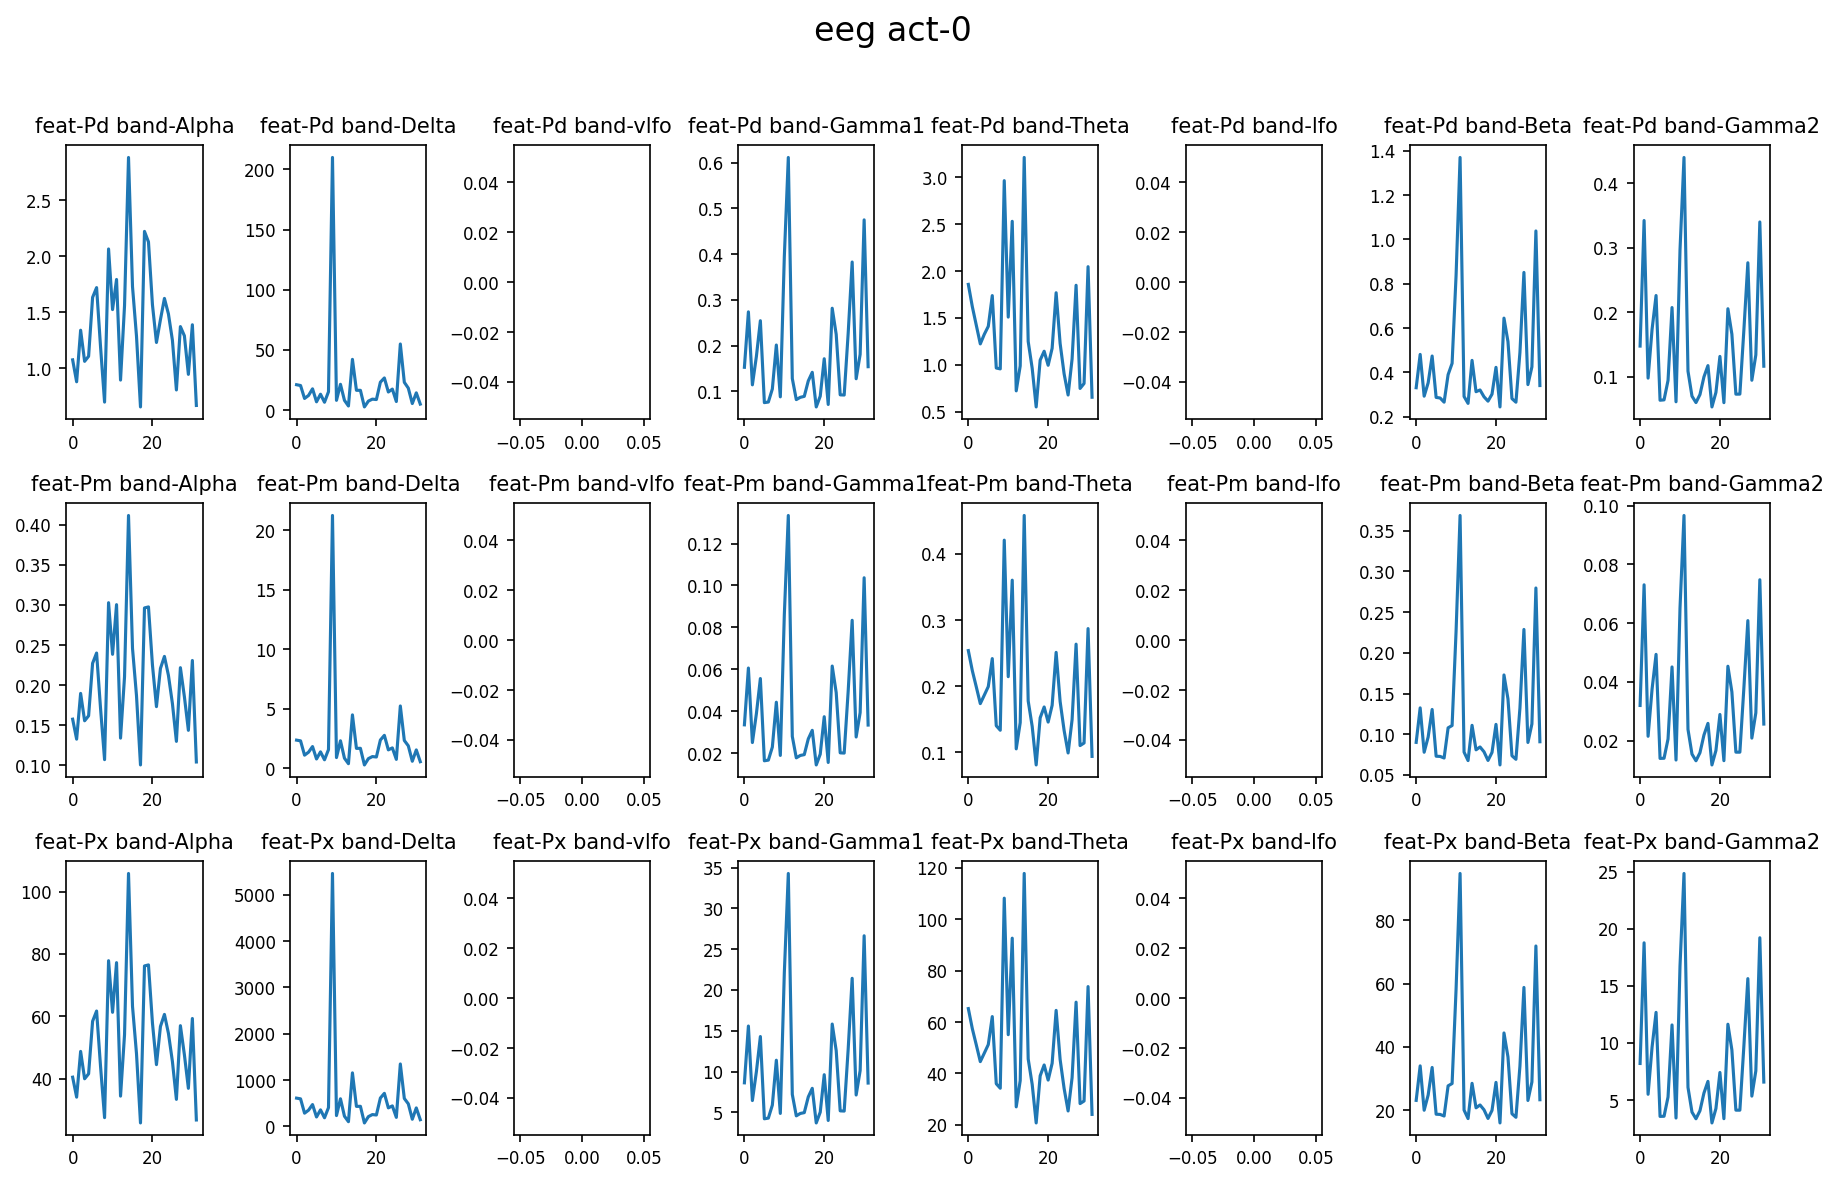

In [48]:
display_one_row(df.iloc[0])